## Load Transect Lines
From TransectInterGDFWater

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from Toolshed import Download, Toolbox, VegetationLine, Plotting, PlottingSeaborn, Transects

# --------------------
# Parameters & loading
# --------------------
# ConnorsCove_BlackBeach  Gooseberry_Cove  Rivermouth_West
sitename = 'Rivermouth_West'
sat_list = ['PSScene4Band']

filepath = '/home/sagemaker-user/COASTGUARD/Data'
intersect_file = os.path.join(filepath, sitename, 'intersections', f'{sitename}_transect_water_intersects.pkl')
veg_intersect_file = os.path.join(filepath, sitename, 'intersections', f'{sitename}_transect_water_intersects.pkl')

with open(intersect_file, 'rb') as f:
    TransectInterGDFWater = pickle.load(f)

print(f"Loaded {len(TransectInterGDFWater)} transects with columns:")
print(TransectInterGDFWater.columns.tolist())

# --------------------
# Config
# --------------------
PEAK_PROMINENCE = 3   # tune 2–6 as needed
MIN_GAP = 3           # drop representatives with |Δ TransectID| <= MIN_GAP (1 = remove immediate neighbors)

# --------------------
# Helpers
# --------------------
def compute_azimuth(line):
    """Bearing from start->end in degrees [0,360) measured from North."""
    if line is None or line.is_empty or line.geom_type != 'LineString':
        return np.nan
    x1, y1 = line.coords[0]
    x2, y2 = line.coords[-1]
    ang = np.degrees(np.arctan2(x2 - x1, y2 - y1))
    return ang % 360

def wrapped_delta(a_prev, a_curr):
    """Signed smallest-angle difference in [-180,180]."""
    return ((a_curr - a_prev + 180.0) % 360.0) - 180.0

def enforce_min_gap_on_candidates(df, candidate_indices, id_col="TransectID", min_gap=1):
    """
    From candidate row indices, keep a subset so successive kept TransectIDs
    differ by > min_gap. (Also removes duplicates / ties.)
    Returns kept row indices (in original df index space).
    """
    # Build a small frame of candidates (dedupe on index)
    cand = (df.loc[list(set(candidate_indices)), [id_col]]
              .dropna()
              .sort_values(id_col))
    keep = []
    last_id = None
    for idx, row in cand.iterrows():
        cur = row[id_col]
        if last_id is None or abs(cur - last_id) > min_gap:
            keep.append(idx)
            last_id = cur
    return keep

# --------------------
# 1) Sort & compute azimuths (kept in memory)
# --------------------
TransectInterGDFWater = TransectInterGDFWater.sort_values("TransectID").reset_index(drop=True).copy()
az = pd.to_numeric(TransectInterGDFWater.geometry.apply(compute_azimuth), errors="coerce")

# --------------------
# 2) Compute |Δ azimuth| (kept in memory only)
# --------------------
delta = np.zeros(len(az), dtype=float)
valid = az.notna().to_numpy()
for i in range(1, len(az)):
    if valid[i] and valid[i-1]:
        delta[i] = abs(wrapped_delta(az.iat[i-1], az.iat[i]))
    else:
        delta[i] = 0.0

# --------------------
# 3) Initial representatives from curvature peaks
# --------------------
peaks, _ = find_peaks(delta, prominence=PEAK_PROMINENCE)
rep_candidates = peaks.tolist()

# Ensure at least the first transect starts a group
if len(rep_candidates) == 0 or rep_candidates[0] != 0:
    rep_candidates = [0] + rep_candidates

# --------------------
# 4) Spacing filter: drop reps that are too close or same TransectID
# --------------------
kept_rep_indices = enforce_min_gap_on_candidates(
    TransectInterGDFWater, rep_candidates, id_col="TransectID", min_gap=MIN_GAP
)

# --------------------
# 5) Write ONLY TWO columns: is_representative (bool) and group (int)
#    Groups are sequential blocks starting at each kept representative.
# --------------------
TransectInterGDFWater["is_representative"] = False
TransectInterGDFWater.loc[kept_rep_indices, "is_representative"] = True

# group = cumulative count of reps (0-based)
TransectInterGDFWater["group"] = TransectInterGDFWater["is_representative"].cumsum() - 1
TransectInterGDFWater["group"] = TransectInterGDFWater["group"].astype(int)

print(
    f"Reps kept: {int(TransectInterGDFWater['is_representative'].sum())} | "
    f"Groups: {TransectInterGDFWater['group'].nunique()} | "
    f"MIN_GAP={MIN_GAP}"
)

/home/sagemaker-user/.conda/envs/coastguard/lib/python3.10/site-packages/geemap/conversion.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Loaded 310 transects with columns:
['LineID', 'TransectID', 'geometry', 'reflinepnt', 'dates', 'times', 'filename', 'cloud_cove', 'idx', 'vthreshold', 'wthreshold', 'tideelev', 'satname', 'interpnt', 'distances', 'olddate', 'youngdate', 'oldyoungT', 'oldyoungRt', 'recentT', 'recentRt', 'normdists', 'wldates', 'wltimes', 'wldists', 'wlinterpnt', 'wlcorrdist', 'tidedatesFD', 'tideelevFD', 'tideelevMx', 'beachslope', 'S_source', 'S_offset_m', 'sign_used', 'beachwidth', 'tidezone', 'olddateW', 'youngdateW', 'oldyoungTW', 'oldyungRtW', 'oldyungMEW', 'recentTW', 'recentRtW', 'recentMEW']
Reps kept: 14 | Groups: 14 | MIN_GAP=3


findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Generic family 'sans-serif' not found because

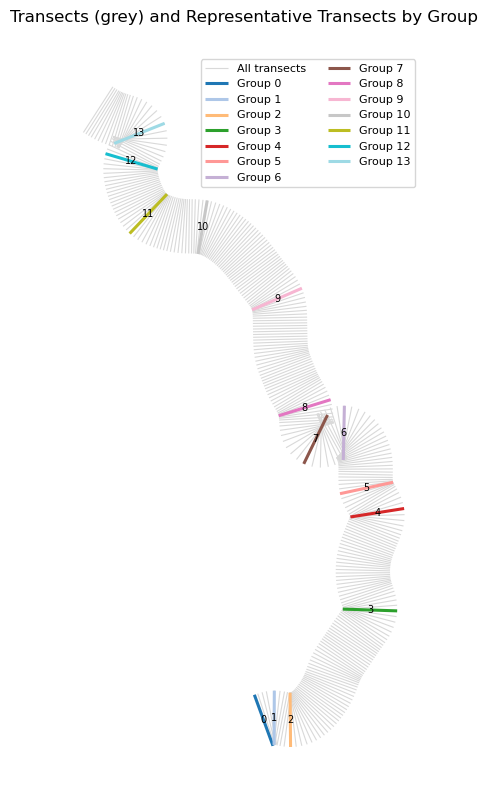

In [2]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Assume you've already loaded this:
# TransectInterGDFWater  (columns: geometry, is_representative, group)

gdf = TransectInterGDFWater.copy()
gdf = gdf.set_geometry("geometry")

# Split full set vs representatives
gdf_all = gdf
gdf_rep = gdf[gdf["is_representative"] == True].copy()

# Build distinct colors per group (for reps)
groups = sorted(gdf_rep["group"].unique())
cmap = cm.get_cmap("tab20", max(len(groups), 1))
group2color = {g: cmap(i) for i, g in enumerate(groups)}

fig, ax = plt.subplots(figsize=(8, 8))

# All transects in light grey
gdf_all.plot(ax=ax, color="0.85", linewidth=0.8, label="All transects")

# Representatives, thicker, colored by group
for g in groups:
    gdf_rep[gdf_rep["group"] == g].plot(
        ax=ax, linewidth=2.2, color=group2color[g], label=f"Group {g}"
    )

# Optional: label representatives (small, unobtrusive)
gdf_rep["centroid"] = gdf_rep.geometry.centroid
for _, r in gdf_rep.iterrows():
    x, y = r["centroid"].x, r["centroid"].y
    ax.text(x, y, str(r["group"]), fontsize=7, ha="center", va="center")

ax.set_title("Transects (grey) and Representative Transects by Group", pad=12)
ax.set_axis_off()
ax.legend(loc="upper right", fontsize=8, frameon=True, ncol=2)
plt.tight_layout()
plt.show()
# plt.savefig("transect_reps.png", dpi=300, bbox_inches="tight")


In [3]:
TransectInterGDFWater.columns

Index(['LineID', 'TransectID', 'geometry', 'reflinepnt', 'dates', 'times',
       'filename', 'cloud_cove', 'idx', 'vthreshold', 'wthreshold', 'tideelev',
       'satname', 'interpnt', 'distances', 'olddate', 'youngdate', 'oldyoungT',
       'oldyoungRt', 'recentT', 'recentRt', 'normdists', 'wldates', 'wltimes',
       'wldists', 'wlinterpnt', 'wlcorrdist', 'tidedatesFD', 'tideelevFD',
       'tideelevMx', 'beachslope', 'S_source', 'S_offset_m', 'sign_used',
       'beachwidth', 'tidezone', 'olddateW', 'youngdateW', 'oldyoungTW',
       'oldyungRtW', 'oldyungMEW', 'recentTW', 'recentRtW', 'recentMEW',
       'is_representative', 'group'],
      dtype='object')

In [4]:
TransectInterGDFWater.to_pickle(intersect_file.replace(".pkl", "_with_groups.pkl"))

In [5]:
sat_list = ['PSScene4Band']

filepath = '/home/sagemaker-user/COASTGUARD/Data'
grouped_intersect_file = os.path.join(filepath, sitename, 'intersections', f'{sitename}_transect_water_intersects_with_groups.pkl')
veg_intersect_file = os.path.join(filepath, sitename, 'intersections', f'{sitename}_transect_intersects.pkl')
wave_intersect_file = intersect_file = os.path.join(filepath, sitename, 'intersections', f'{sitename}_transect_wave_intersects.pkl')
topo_intersect_file = os.path.join(filepath, sitename, 'intersections', f'{sitename}_transect_topo_intersects.pkl')

with open(grouped_intersect_file, 'rb') as f:
    TransectInterGDFWater = pickle.load(f)
with open(veg_intersect_file, 'rb') as f:
    TransectInterGDFVeg = pickle.load(f)
with open(wave_intersect_file, 'rb') as f:
    TransectInterGDFWave = pickle.load(f)
with open(topo_intersect_file, 'rb') as f:
    TransectInterGDFTopo = pickle.load(f)
    
print(f"Loaded TransectInterGDFWater:")
print(TransectInterGDFWater.columns.tolist())

print(f"Loaded TransectInterGDFVeg:")
print(TransectInterGDFVeg.columns.tolist())

print(f"Loaded TransectInterGDFWave:")
print(TransectInterGDFWave.columns.tolist())

print(f"Loaded TransectInterGDFTopo:")
print(TransectInterGDFTopo.columns.tolist())

Loaded TransectInterGDFWater:
['LineID', 'TransectID', 'geometry', 'reflinepnt', 'dates', 'times', 'filename', 'cloud_cove', 'idx', 'vthreshold', 'wthreshold', 'tideelev', 'satname', 'interpnt', 'distances', 'olddate', 'youngdate', 'oldyoungT', 'oldyoungRt', 'recentT', 'recentRt', 'normdists', 'wldates', 'wltimes', 'wldists', 'wlinterpnt', 'wlcorrdist', 'tidedatesFD', 'tideelevFD', 'tideelevMx', 'beachslope', 'S_source', 'S_offset_m', 'sign_used', 'beachwidth', 'tidezone', 'olddateW', 'youngdateW', 'oldyoungTW', 'oldyungRtW', 'oldyungMEW', 'recentTW', 'recentRtW', 'recentMEW', 'is_representative', 'group']
Loaded TransectInterGDFVeg:
['LineID', 'TransectID', 'geometry', 'reflinepnt', 'dates', 'times', 'filename', 'cloud_cove', 'idx', 'vthreshold', 'wthreshold', 'tideelev', 'satname', 'interpnt', 'distances', 'olddate', 'youngdate', 'oldyoungT', 'oldyoungRt', 'recentT', 'recentRt', 'normdists']
Loaded TransectInterGDFWave:
['LineID', 'TransectID', 'geometry', 'reflinepnt', 'dates', 'tim

In [6]:
TransectInterGDFWater.geometry

0      LINESTRING (715717.476 5005475.719, 715786.059...
1      LINESTRING (715729.882 5005480.063, 715792.523...
2      LINESTRING (715745.942 5005484.924, 715795.566...
3      LINESTRING (715761.554 5005488.449, 715799.450...
4      LINESTRING (715790.983 5005491.020, 715789.938...
                             ...                        
305    LINESTRING (715128.993 5007521.847, 715223.727...
306    LINESTRING (715116.490 5007528.833, 715218.750...
307    LINESTRING (715106.678 5007534.774, 715211.454...
308    LINESTRING (715096.896 5007540.942, 715204.324...
309    LINESTRING (715087.940 5007546.697, 715196.454...
Name: geometry, Length: 310, dtype: geometry